# Introduction: 
Grabbing the Data from kaggle: https://www.kaggle.com/competitions/home-credit-default-risk/data

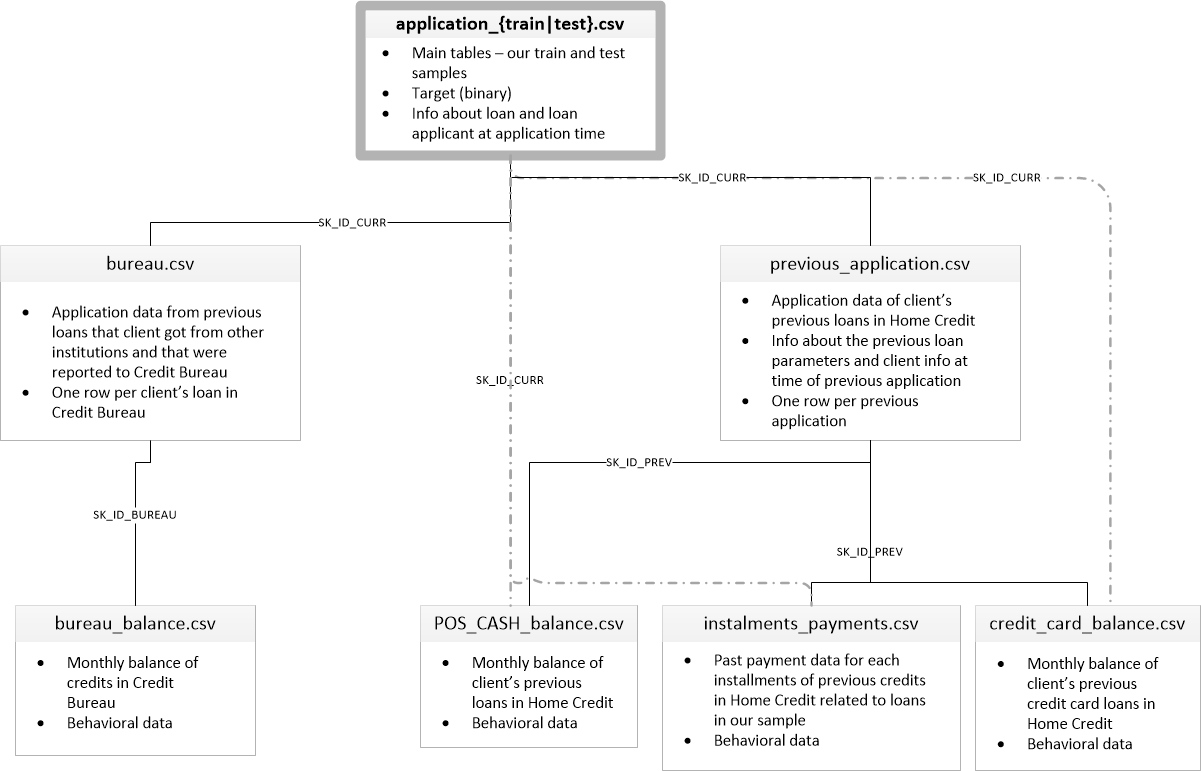

In [1]:
import sqlite3
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

conn = sqlite3.connect(r"C:\Data_Projects\Project_2_Data4401\home_credit.db")

# Data Exploration
This section is for exploring the data. Understanding what it represent and how it works. Moreover, we need to understand what our goal with this data is and why we are using it. To begin, lets look at each individual table. As we can see there is a relational table built well above that allows us to see which tables can merge to each other and what unique key ids there are. 

In [2]:
bureau_combined_df = pd.read_sql("""
SELECT b.*, bb.MONTHS_BALANCE, bb.STATUS
FROM bureau AS b
LEFT JOIN bureau_balance AS bb
    ON b.SK_ID_BUREAU = bb.SK_ID_BUREAU
LIMIT 500000
""", conn)



print(f"Shape: {bureau_combined_df.shape}")
print("-"*1000)
print(bureau_combined_df.info())

Shape: (500000, 19)
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [3]:
pd.set_option("display.max_columns", None)

bureau_combined_df.head(10)

,SK_ID_BUREAU,SK_ID_CURR,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,MONTHS_BALANCE,STATUS
0,5000000,166497,Closed,currency 1,-2918,0,-2613.0,-2639.0,NaN,0,29443.50,0.00,NaN,0.0,Consumer credit,-2512,NaN,NaN,NaN
1,5000001,166497,Closed,currency 1,-1015,0,-831.0,-891.0,2223.855,0,13810.50,0.00,0.0,0.0,Consumer credit,-891,NaN,NaN,NaN
2,5000002,166497,Closed,currency 1,-149,0,-26.0,-26.0,0.000,0,13455.00,0.00,0.0,0.0,Consumer credit,-23,NaN,NaN,NaN
3,5000003,166497,Closed,currency 1,-135,0,230.0,-42.0,0.000,0,37350.00,0.00,0.0,0.0,Consumer credit,-42,NaN,NaN,NaN
4,5000004,166497,Active,currency 1,-47,0,320.0,NaN,0.000,0,315127.62,315127.62,0.0,0.0,Consumer credit,-17,NaN,NaN,NaN
5,5000005,356385,Active,currency 1,-459,0,148.0,NaN,NaN,0,270000.00,84505.50,0.0,0.0,Consumer credit,-32,NaN,NaN,NaN
6,5000006,375916,Closed,currency 1,-2850,0,-1756.0,-2227.0,NaN,0,900000.00,0.00,NaN,0.0,Loan for business development,-2227,NaN,NaN,NaN
7,5000009,375916,Closed,currency 1,-2581,0,-765.0,-757.0,NaN,0,1350000.00,0.00,NaN,0.0,Loan for business development,-757,NaN,NaN,NaN
8,5000010,375916,Closed,currency 1,-352,0,-332.0,-334.0,NaN,0,22500.00,0.00,NaN,0.0,Microloan,-327,NaN,NaN,NaN
9,5000011,375916,Active,currency 1,-20,0,10.0,NaN,NaN,0,27000.00,29025.00,NaN,0.0,Microloan,-15,NaN,NaN,NaN


In [4]:
columns_str = bureau_combined_df.select_dtypes(include=["object", "string"]).columns.tolist()


for col in columns_str:
    print(f"\n --- {col}--- ")
    print(bureau_combined_df[col].value_counts(dropna=False))


 --- CREDIT_ACTIVE--- 
CREDIT_ACTIVE
Closed    380129
Active    117170
Sold        2701
Name: count, dtype: int64

 --- CREDIT_CURRENCY--- 
CREDIT_CURRENCY
currency 1    499366
currency 2       552
currency 4        51
currency 3        31
Name: count, dtype: int64

 --- CREDIT_TYPE--- 
CREDIT_TYPE
Consumer credit                           379402
Credit card                               104131
Car loan                                    9173
Mortgage                                    4705
Microloan                                   1113
Loan for business development                748
Another type of loan                         448
Unknown type of loan                         138
Loan for working capital replenishment        80
Cash loan (non-earmarked)                     61
Real estate loan                               1
Name: count, dtype: int64

 --- STATUS--- 
STATUS
C      229888
0      149197
X      103414
NaN     12049
1        4157
5         725
2         346
3         13

In [5]:
bureau_combined_df.describe()

,SK_ID_BUREAU,SK_ID_CURR,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,MONTHS_BALANCE
count,5.000000e+05,500000.000000,500000.000000,500000.000000,474023.000000,380993.000000,1.433790e+05,500000.000000,5.000000e+05,4.121430e+05,2.675590e+05,500000.000000,500000.000000,2.896120e+05,487951.000000
mean,5.013806e+06,278189.516198,-1563.489286,0.497708,48.879943,-1240.431060,4.600621e+03,0.005396,3.328002e+05,9.197203e+04,5.011083e+03,8.134465,-806.408788,1.118778e+04,-27.314173
std,8.444261e+03,103311.192653,752.704479,30.968447,4921.283496,699.230194,3.402968e+04,0.089235,8.555831e+05,6.297717e+05,4.369717e+04,417.289351,698.225231,6.969352e+04,21.386314
min,5.000000e+06,100057.000000,-2922.000000,0.000000,-41847.000000,-2860.000000,0.000000e+00,0.000000,0.000000e+00,-1.354876e+06,-3.163919e+05,0.000000,-41878.000000,0.000000e+00,-96.000000
25%,5.005186e+06,190167.000000,-2193.000000,0.000000,-1616.000000,-1763.000000,0.000000e+00,0.000000,5.103000e+04,0.000000e+00,0.000000e+00,0.000000,-1199.000000,0.000000e+00,-40.000000
50%,5.012178e+06,274893.000000,-1507.000000,0.000000,-875.000000,-1177.000000,0.000000e+00,0.000000,1.215000e+05,0.000000e+00,0.000000e+00,0.000000,-733.000000,0.000000e+00,-22.000000
75%,5.021943e+06,369712.000000,-968.000000,0.000000,-44.000000,-682.000000,0.000000e+00,0.000000,3.028500e+05,0.000000e+00,0.000000e+00,0.000000,-143.000000,8.717625e+03,-10.000000
max,5.029485e+06,456220.000000,0.000000,2623.000000,31182.000000,-1.000000,3.165502e+06,3.000000,4.905000e+07,4.740686e+07,1.354876e+06,51117.480000,0.000000,2.263752e+06,0.000000


# Beareau Data (META DATA)
- Application data from previous loans that clients get from other institutions and that were reported to Credi Burea.
- On row per client's loan in Credit Burau
- Monthly balance of credits in Credit
- Behavioral data 


In [6]:
del bureau_combined_df

In [7]:
previous_combined_df = pd.read_sql("""
SELECT *
FROM previous_application
LIMIT 50000
""", conn)

print(f"shape: {previous_combined_df.shape}")
print("-"*100)
print(previous_combined_df.info())

shape: (50000, 37)
----------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SK_ID_PREV                   50000 non-null  int64  
 1   SK_ID_CURR                   50000 non-null  int64  
 2   NAME_CONTRACT_TYPE           50000 non-null  str    
 3   AMT_ANNUITY                  40425 non-null  float64
 4   AMT_APPLICATION              50000 non-null  float64
 5   AMT_CREDIT                   50000 non-null  float64
 6   AMT_DOWN_PAYMENT             25172 non-null  float64
 7   AMT_GOODS_PRICE              39836 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   50000 non-null  str    
 9   HOUR_APPR_PROCESS_START      50000 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  50000 non-null  str    
 11  NFLAG_LAST_APPL_IN_DAY 

In [8]:
previous_combined_df.head(10)

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,1000001,158271,Consumer loans,6404.310,58905.000,65124.0,0.000,58905.000,THURSDAY,8,Y,1,0.000000,NaN,NaN,XAP,Approved,-299,Cash through the bank,XAP,NaN,New,Furniture,POS,XNA,Stone,70,Furniture,12.0,middle,POS industry with interest,365243.0,-268.0,62.0,-238.0,-233.0,0.0
1,1000002,101962,Consumer loans,6264.000,39145.500,35230.5,3915.000,39145.500,SUNDAY,8,Y,1,0.108922,NaN,NaN,XAP,Approved,-1634,Cash through the bank,XAP,Unaccompanied,Repeater,Audio/Video,POS,XNA,Country-wide,1780,Consumer electronics,6.0,low_normal,POS household with interest,365243.0,-1600.0,-1450.0,-1510.0,-1501.0,0.0
2,1000003,252457,Consumer loans,4951.350,47056.275,52641.0,4.275,47056.275,SUNDAY,13,Y,1,0.000088,NaN,NaN,XAP,Approved,-124,Cash through the bank,XAP,Unaccompanied,Refreshed,Audio/Video,POS,XNA,Country-wide,1103,Consumer electronics,12.0,low_action,POS household without interest,365243.0,-94.0,236.0,365243.0,365243.0,1.0
3,1000004,260094,Consumer loans,3391.110,35144.370,30586.5,7032.870,35144.370,THURSDAY,9,Y,1,0.203603,NaN,NaN,XAP,Approved,-893,XNA,XAP,Unaccompanied,Refreshed,Audio/Video,POS,XNA,Country-wide,1103,Consumer electronics,10.0,low_normal,POS household without interest,365243.0,-862.0,-592.0,-682.0,-672.0,0.0
4,1000005,176456,Consumer loans,14713.605,123486.075,120307.5,12349.575,123486.075,THURSDAY,13,Y,1,0.101388,NaN,NaN,XAP,Approved,-1719,Cash through the bank,XAP,Family,New,Construction Materials,POS,XNA,Stone,1877,Construction,10.0,middle,POS industry with interest,365243.0,-1688.0,-1418.0,-1418.0,-1415.0,0.0
5,1000006,427505,Consumer loans,10572.345,51417.000,51417.0,0.000,51417.000,WEDNESDAY,13,Y,1,0.000000,NaN,NaN,XAP,Approved,-264,XNA,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,12,Connectivity,6.0,high,POS mobile with interest,NaN,NaN,NaN,NaN,NaN,NaN
6,1000007,256657,Consumer loans,11246.805,78570.000,62856.0,15714.000,78570.000,SUNDAY,13,Y,1,0.217818,NaN,NaN,XAP,Approved,-158,Cash through the bank,XAP,Unaccompanied,Repeater,Consumer Electronics,POS,XNA,Stone,70,Consumer electronics,6.0,low_normal,POS household with interest,365243.0,-123.0,27.0,365243.0,365243.0,0.0
7,1000008,152059,Consumer loans,26331.660,249255.000,224325.0,24930.000,249255.000,MONDAY,14,Y,1,0.108929,NaN,NaN,XAP,Approved,-1313,Cash through the bank,XAP,Family,New,Consumer Electronics,POS,XNA,Regional / Local,121,Consumer electronics,10.0,middle,POS household with interest,365243.0,-1282.0,-1012.0,-1042.0,-1034.0,0.0
8,1000009,343078,Consumer loans,9302.850,42705.000,45243.0,0.000,42705.000,SATURDAY,11,Y,1,0.000000,NaN,NaN,XAP,Approved,-488,Cash through the bank,XAP,Unaccompanied,Repeater,Consumer Electronics,POS,XNA,Regional / Local,121,Consumer electronics,6.0,high,POS household with interest,365243.0,-457.0,-307.0,-307.0,-305.0,0.0
9,1000010,377567,Cash loans,74682.000,900000.000,900000.0,NaN,900000.000,THURSDAY,17,Y,1,NaN,NaN,NaN,XNA,Approved,-588,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Regional / Local,121,Consumer electronics,18.0,high,Cash X-Sell: high,365243.0,-558.0,-48.0,-258.0,-256.0,0.0


In [9]:
previous_combined_info = previous_combined_df.drop(columns=["SK_ID_PREV", "SK_ID_CURR"])

previous_combined_info.describe()

,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,HOUR_APPR_PROCESS_START,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,DAYS_DECISION,SELLERPLACE_AREA,CNT_PAYMENT,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
count,40425.000000,5.000000e+04,5.000000e+04,2.517200e+04,3.983600e+04,50000.000000,50000.000000,25172.000000,211.000000,211.000000,50000.000000,50000.000000,40425.000000,32702.000000,32702.000000,32702.00000,32702.000000,32702.000000,32702.000000
mean,15316.347554,1.692696e+05,1.892433e+05,6.724259e+03,2.125033e+05,12.445240,0.996780,0.079767,0.183210,0.780302,-927.139000,334.239040,15.304391,341495.914256,13368.269739,33752.74549,75098.976240,80992.228182,0.320928
std,14418.155217,2.804928e+05,3.051959e+05,2.323005e+04,2.993322e+05,3.336451,0.056654,0.106460,0.073063,0.091957,791.270659,1706.896747,13.782595,90195.215879,71399.096093,106857.38053,148597.282922,152652.879561,0.466840
min,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.059135,0.424419,-2922.000000,-1.000000,0.000000,-2919.000000,-2892.000000,-2801.00000,-2869.000000,-2791.000000,0.000000
25%,6067.710000,2.380050e+04,2.830500e+04,0.000000e+00,4.855050e+04,10.000000,1.000000,0.000000,0.160716,0.715645,-1396.000000,-1.000000,6.000000,365243.000000,-1647.750000,-1259.00000,-1328.000000,-1282.000000,0.000000
50%,10751.985000,7.200000e+04,8.137125e+04,1.800000e+03,1.035000e+05,12.000000,1.000000,0.063281,0.189122,0.835095,-638.000000,14.000000,12.000000,365243.000000,-841.000000,-370.00000,-545.000000,-505.000000,0.000000
75%,19355.670000,1.800000e+05,2.025000e+05,7.753500e+03,2.250000e+05,15.000000,1.000000,0.108909,0.193330,0.852537,-304.000000,100.000000,18.000000,365243.000000,-419.000000,121.00000,-82.000000,-50.000000,1.000000
max,215373.510000,3.825000e+06,4.045712e+06,1.980000e+06,3.825000e+06,23.000000,1.000000,0.876709,0.902924,0.867336,-2.000000,120000.000000,84.000000,365243.000000,365243.000000,365243.00000,365243.000000,365243.000000,1.000000


In [10]:
del previous_combined_info

In [11]:
previous_columns = previous_combined_df.select_dtypes(include=["object", "str"]).columns.to_list()

for col in previous_columns:
    print(f"\n --- {col} ---")
    print(previous_combined_df[col].value_counts())


 --- NAME_CONTRACT_TYPE ---
NAME_CONTRACT_TYPE
Consumer loans     23839
Cash loans         20344
Revolving loans     5810
XNA                    7
Name: count, dtype: int64

 --- WEEKDAY_APPR_PROCESS_START ---
WEEKDAY_APPR_PROCESS_START
FRIDAY       7575
TUESDAY      7563
WEDNESDAY    7531
THURSDAY     7459
MONDAY       7444
SATURDAY     7315
SUNDAY       5113
Name: count, dtype: int64

 --- FLAG_LAST_APPL_PER_CONTRACT ---
FLAG_LAST_APPL_PER_CONTRACT
Y    49767
N      233
Name: count, dtype: int64

 --- NAME_CASH_LOAN_PURPOSE ---
NAME_CASH_LOAN_PURPOSE
XAP                                 29656
XNA                                 18420
Repairs                               630
Other                                 399
Urgent needs                          221
Buying a used car                      83
Building a house or an annex           80
Medicine                               67
Everyday expenses                      61
Payments on other loans                60
Education           

# Merging All Tables (Train Only)
The history tables have many rows per client (loans, months, payments), so they can't be joined directly — that would multiply rows. Instead, each table is summarised to **one row per client** (`SK_ID_CURR`) and then left-joined onto the train applications.

- `bureau` + `bureau_balance` → outside loans: count, debt, overdue amounts, worst lateness status
- `previous_application` → past Home Credit applications: count, % refused, amounts
- `pos_cash_balance`, `credit_card_balance`, `installments_payments` → how the client paid Home Credit: days past due, card utilization, % late / underpaid payments

Clients with no history in a table get `NaN` for that table's columns. The query takes ~4 minutes, so the result is cached to `data/processed/train_merged.parquet` and reloaded from there afterwards.

In [12]:
from pathlib import Path

MERGED_PATH = Path(r"C:\Data_Projects\Project_2_Data4401\data\processed\train_merged.parquet")

MERGE_SQL = """
WITH train AS (
    SELECT SK_ID_CURR FROM application WHERE dataset = 'train'
),

-- bureau_balance -> one row per outside loan
bb AS (
    SELECT SK_ID_BUREAU,
        COUNT(*) AS bb_months,
        AVG(STATUS IN ('1','2','3','4','5')) AS bb_pct_late,
        MAX(CASE WHEN STATUS IN ('1','2','3','4','5') THEN CAST(STATUS AS INT) ELSE 0 END) AS bb_worst_status
    FROM bureau_balance
    GROUP BY SK_ID_BUREAU
),

-- bureau (+ bb) -> one row per client
bureau_agg AS (
    SELECT b.SK_ID_CURR,
        COUNT(*) AS bureau_n_loans,
        SUM(b.CREDIT_ACTIVE = 'Active') AS bureau_n_active,
        SUM(b.CREDIT_ACTIVE = 'Closed') AS bureau_n_closed,
        SUM(b.AMT_CREDIT_SUM) AS bureau_total_credit,
        SUM(b.AMT_CREDIT_SUM_DEBT) AS bureau_total_debt,
        SUM(b.AMT_CREDIT_SUM_OVERDUE) AS bureau_total_overdue,
        MAX(b.AMT_CREDIT_MAX_OVERDUE) AS bureau_max_overdue,
        SUM(b.AMT_CREDIT_SUM_DEBT) / NULLIF(SUM(b.AMT_CREDIT_SUM), 0) AS bureau_debt_ratio,
        MIN(b.DAYS_CREDIT) AS bureau_oldest_loan_days,
        MAX(b.DAYS_CREDIT) AS bureau_newest_loan_days,
        MAX(b.CREDIT_DAY_OVERDUE) AS bureau_max_days_overdue,
        SUM(b.CNT_CREDIT_PROLONG) AS bureau_n_prolonged,
        AVG(bb.bb_pct_late) AS bureau_avg_pct_months_late,
        MAX(bb.bb_worst_status) AS bureau_worst_status
    FROM bureau AS b
    JOIN train USING (SK_ID_CURR)
    LEFT JOIN bb ON b.SK_ID_BUREAU = bb.SK_ID_BUREAU
    GROUP BY b.SK_ID_CURR
),

-- previous Home Credit applications -> one row per client
prev_agg AS (
    SELECT p.SK_ID_CURR,
        COUNT(*) AS prev_n_apps,
        SUM(p.NAME_CONTRACT_STATUS = 'Approved') AS prev_n_approved,
        SUM(p.NAME_CONTRACT_STATUS = 'Refused') AS prev_n_refused,
        AVG(p.NAME_CONTRACT_STATUS = 'Refused') AS prev_pct_refused,
        AVG(p.AMT_APPLICATION) AS prev_avg_amt_applied,
        AVG(p.AMT_CREDIT) AS prev_avg_amt_credit,
        AVG(p.AMT_CREDIT / NULLIF(p.AMT_APPLICATION, 0)) AS prev_avg_credit_to_applied,
        AVG(p.AMT_ANNUITY) AS prev_avg_annuity,
        AVG(p.CNT_PAYMENT) AS prev_avg_n_payments,
        MAX(p.DAYS_DECISION) AS prev_last_decision_days,
        AVG(p.RATE_DOWN_PAYMENT) AS prev_avg_down_payment_rate
    FROM previous_application AS p
    JOIN train USING (SK_ID_CURR)
    GROUP BY p.SK_ID_CURR
),

-- POS / cash loan months -> one row per client
pos_agg AS (
    SELECT p.SK_ID_CURR,
        COUNT(DISTINCT p.SK_ID_PREV) AS pos_n_loans,
        COUNT(*) AS pos_n_months,
        MAX(p.SK_DPD) AS pos_max_dpd,
        AVG(p.SK_DPD > 0) AS pos_pct_months_dpd,
        AVG(p.CNT_INSTALMENT_FUTURE) AS pos_avg_instalments_left
    FROM pos_cash_balance AS p
    JOIN train USING (SK_ID_CURR)
    GROUP BY p.SK_ID_CURR
),

-- credit card months -> one row per client
cc_agg AS (
    SELECT c.SK_ID_CURR,
        COUNT(DISTINCT c.SK_ID_PREV) AS cc_n_cards,
        COUNT(*) AS cc_n_months,
        AVG(c.AMT_BALANCE) AS cc_avg_balance,
        MAX(c.AMT_BALANCE) AS cc_max_balance,
        AVG(c.AMT_BALANCE / NULLIF(c.AMT_CREDIT_LIMIT_ACTUAL, 0)) AS cc_avg_utilization,
        MAX(c.AMT_BALANCE / NULLIF(c.AMT_CREDIT_LIMIT_ACTUAL, 0)) AS cc_max_utilization,
        AVG(c.AMT_DRAWINGS_CURRENT) AS cc_avg_drawings,
        MAX(c.SK_DPD) AS cc_max_dpd,
        AVG(c.SK_DPD > 0) AS cc_pct_months_dpd
    FROM credit_card_balance AS c
    JOIN train USING (SK_ID_CURR)
    GROUP BY c.SK_ID_CURR
),

-- installment payments -> one row per client
inst_agg AS (
    SELECT i.SK_ID_CURR,
        COUNT(*) AS inst_n_payments,
        AVG(i.DAYS_ENTRY_PAYMENT > i.DAYS_INSTALMENT) AS inst_pct_late,
        AVG(MAX(i.DAYS_ENTRY_PAYMENT - i.DAYS_INSTALMENT, 0)) AS inst_avg_days_late,
        MAX(i.DAYS_ENTRY_PAYMENT - i.DAYS_INSTALMENT) AS inst_max_days_late,
        AVG(i.AMT_PAYMENT < i.AMT_INSTALMENT) AS inst_pct_underpaid,
        SUM(MAX(i.AMT_INSTALMENT - i.AMT_PAYMENT, 0)) AS inst_total_shortfall,
        AVG(i.AMT_PAYMENT / NULLIF(i.AMT_INSTALMENT, 0)) AS inst_avg_paid_ratio
    FROM installments_payments AS i
    JOIN train USING (SK_ID_CURR)
    GROUP BY i.SK_ID_CURR
)

SELECT *
FROM v_application_full AS a
LEFT JOIN bureau_agg AS b USING (SK_ID_CURR)
LEFT JOIN prev_agg   AS p USING (SK_ID_CURR)
LEFT JOIN pos_agg    AS pos USING (SK_ID_CURR)
LEFT JOIN cc_agg     AS cc USING (SK_ID_CURR)
LEFT JOIN inst_agg   AS i USING (SK_ID_CURR)
WHERE a.dataset = 'train'
"""

if MERGED_PATH.exists():
    train_merged = pd.read_parquet(MERGED_PATH)
else:
    # Bigger SQLite cache: cuts the query from ~10 min to ~4 min
    conn.execute("PRAGMA mmap_size = 4000000000")
    conn.execute("PRAGMA cache_size = -2000000")
    conn.execute("PRAGMA temp_store = MEMORY")
    train_merged = pd.read_sql(MERGE_SQL, conn)
    MERGED_PATH.parent.mkdir(parents=True, exist_ok=True)
    train_merged.to_parquet(MERGED_PATH, index=False)

print(f"Shape: {train_merged.shape}")
train_merged.head()

Shape: (307511, 169)


,SK_ID_CURR,dataset,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,bureau_n_loans,bureau_n_active,bureau_n_closed,bureau_total_credit,bureau_total_debt,bureau_total_overdue,bureau_max_overdue,bureau_debt_ratio,bureau_oldest_loan_days,bureau_newest_loan_days,bureau_max_days_overdue,bureau_n_prolonged,bureau_avg_pct_months_late,bureau_worst_status,prev_n_apps,prev_n_approved,prev_n_refused,prev_pct_refused,prev_avg_amt_applied,prev_avg_amt_credit,prev_avg_credit_to_applied,prev_avg_annuity,prev_avg_n_payments,prev_last_decision_days,prev_avg_down_payment_rate,pos_n_loans,pos_n_months,pos_max_dpd,pos_pct_months_dpd,pos_avg_instalments_left,cc_n_cards,cc_n_months,cc_avg_balance,cc_max_balance,cc_avg_utilization,cc_max_utilization,cc_avg_drawings,cc_max_dpd,cc_pct_months_dpd,inst_n_payments,inst_pct_late,inst_avg_days_late,inst_max_days_late,inst_pct_underpaid,inst_total_shortfall,inst_avg_paid_ratio
0,100002,train,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,8.0,2.0,6.0,865055.565,245781.0,0.0,5043.645,0.284122,-1437.0,-103.0,0.0,0.0,0.255682,1.0,1.0,1.0,0.0,0.000000,179055.00,179055.00,1.000000,9251.775,24.000000,-606.0,0.000000,1.0,19.0,0.0,0.0,15.000000,NaN,NaN,NaN,NaN,

In [13]:
train_merged.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 169 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    dataset                       307511 non-null  str    
 2    TARGET                        307511 non-null  int64  
 3    NAME_CONTRACT_TYPE            307511 non-null  str    
 4    CODE_GENDER                   307511 non-null  str    
 5    FLAG_OWN_CAR                  307511 non-null  str    
 6    FLAG_OWN_REALTY               307511 non-null  str    
 7    CNT_CHILDREN                  307511 non-null  int64  
 8    AMT_INCOME_TOTAL              307511 non-null  float64
 9    AMT_CREDIT                    307511 non-null  float64
 10   AMT_ANNUITY                   307499 non-null  float64
 11   AMT_GOODS_PRICE               307233 non-null  float64
 12   NAME_TYPE_SUITE               306219 no

# What we did here:
Due to the sheer amount of data that the historical records on payments and other things an applicant has inorder to determine if they're struggling is too big to model and too much for our current equiment to use. To handle this, we summarized the historical tables: bureau, buarea_balance, previous_application, pos_cash_balance, credit_card_balance, and instalments_payments. So that we can create a general gist of a candidates background of their financial spending. 

# NOTE:
One compromise of doing this approach is that it gets rid of historical order, Most Categorical history (weather previous loans were cash or onsumer loans), and a few numerical columns (This is mainly the primary keys or unique keys). 

In [14]:
train_merged.TARGET.value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

There is a apparent class imabalnce. The issue with the fairness within our model we may come accross are underfitting and bias. This is a problem but will be handled using Stratified sampling. Using Stratified sampling on our data will allow us to handle this issue. 

Because of the sheer size of this data set, it may be smart to first use a model such as Random Forrest to help us assist in finding which feature's entropy was used the most. This will help us gain insight and a general idea on what factors heavily influence a person's TARGET Classifier. **LightGBM** We will also use to set a basis or standard for our Neural network to compete.  

# Random Forrest Exploration

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer #This will help us transform and encode strings
from sklearn.impute import SimpleImputer # help us handle NAN values by calculating means and medians or even the most frequent number
from sklearn.preprocessing import OrdinalEncoder # converts categorical text into integer columns
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance # what features are relied on the most
from sklearn.feature_selection import mutual_info_classif #statistical side of a model's decision

In [16]:
df = train_merged.copy()

df["NO_EMPLOYER"] = (df["DAYS_EMPLOYED"] == 365243).astype(int) # flag this down because this is just an encoding issue.
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

y = df["TARGET"].astype(int)
X = df.drop(columns=["SK_ID_CURR", "TARGET", "dataset"])

cat_cols = X.select_dtypes(include=["object", "str"]).columns.to_list()
num_col = [c for c in X.columns if c not in cat_cols]

X[cat_cols] = X[cat_cols].fillna("MISSING")

print(f"{len(num_col)} numeric, {len(cat_cols)} categorical features") 

151 numeric, 16 categorical features


# Random Forrest Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
) # NOTE The Stratify part wihtin our test plit

print(f"Training size: {X_train.shape},")
print(f"Test: {X_test.shape}")

Training size: (246008, 167),
Test: (61503, 167)


In [18]:
# using this will help us fill any gaps numerical data with the median. Morevoer add a 0/1 to any colummns with any missing
preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median", add_indicator=True), num_col),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols)
    ],
    verbose_feature_names_out=False, #Gets rid of any prefix adjustments
)

Random_Forest = RandomForestClassifier(
    n_estimators=300,
    criterion="entropy",
    max_features="sqrt",
    min_samples_leaf=50,
    max_samples=0.5,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=420
)

model = Pipeline([("prep", preprocess), ("rf", Random_Forest)])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](167,)","['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR',..., 'inst_total_shortfall','inst_avg_paid_ratio','NO_EMPLOYER']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,167
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feat

In [19]:
train_proba = model.predict_proba(X_train)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)


print(f"Train ROC AUC: {roc_auc_score(y_train, train_proba):.2}") #most important to note
print(f"Test ROC AUC: {roc_auc_score(y_test, test_proba):.2}")
print(f"Test PR AUC: {average_precision_score(y_test, test_proba):.2}  (random guessing = {y_test.mean():.2})")
print("-"*1000)
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred, digits=3))

Train ROC AUC: 0.87
Test ROC AUC: 0.76
Test PR AUC: 0.24  (random guessing = 0.081)
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

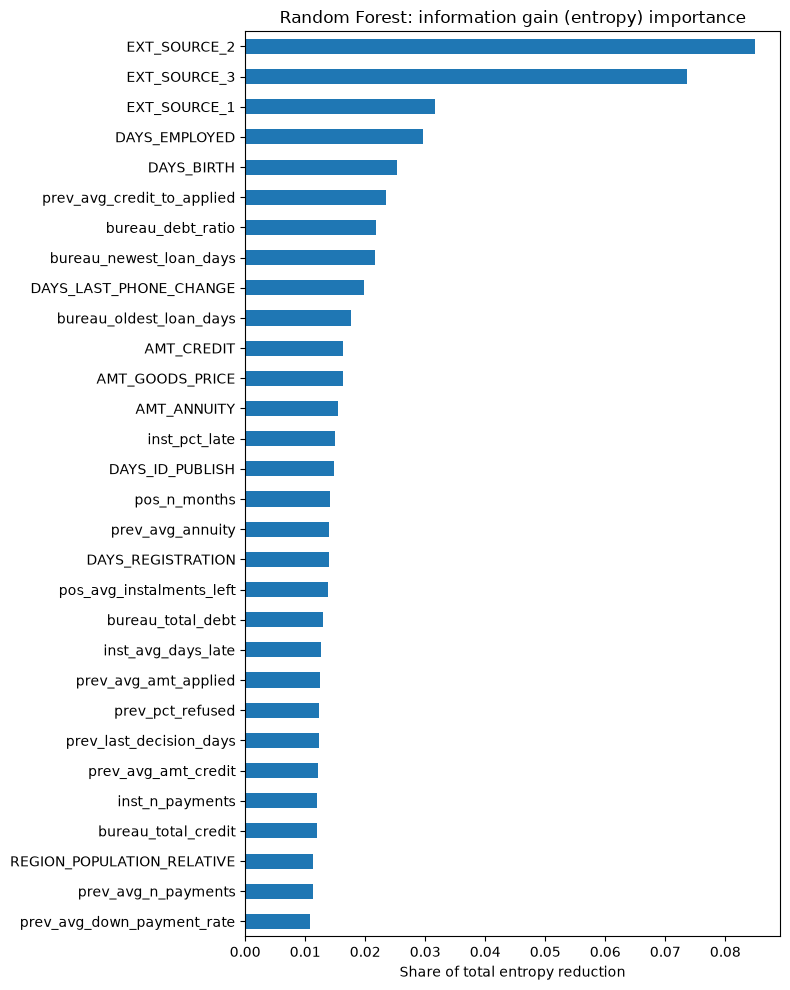

In [20]:
feature_names = model.named_steps["prep"].get_feature_names_out()

entropy_imp = pd.Series(
    model.named_steps["rf"].feature_importances_, index=feature_names
).sort_values(ascending=False)

entropy_imp.head(30).sort_values().plot.barh(figsize=(8, 10)) #Grabbing the top used features from the random forest
plt.title("Random Forest: information gain (entropy) importance")
plt.xlabel("Share of total entropy reduction")
plt.tight_layout()
plt.show()

From looking at the Entropy information alone, we can see the EXT_SOURCES;  1, 2, 3 which are credit scores from the big 3 credit score companies, they were the biggest indicators and relied on the most by the Random Forest in determining if a person was struggling to make payments or not. 

Undoubtedly, this was already apparent to us especially with common knowledge that credit score is a reflection of one's spending along with their ability to pay back debt. 

In [21]:
X_perm = X_test.sample(20000, random_state=420) 
y_perm = y_test.loc[X_perm.index] # making sure the y_perm matches up with the data from the X_perm

perm = permutation_importance(
    model, X_perm, y_perm, scoring="roc_auc", n_repeats=3, random_state=420, n_jobs=1
)

perm_imp = pd.Series(perm.importances_mean, index=X_perm.columns).sort_values(ascending=False)
perm_imp.head(30)

EXT_SOURCE_2                  0.026099
EXT_SOURCE_3                  0.018833
EXT_SOURCE_1                  0.008514
DAYS_EMPLOYED                 0.002795
prev_avg_credit_to_applied    0.002641
NAME_EDUCATION_TYPE           0.002347
pos_n_months                  0.002242
DAYS_LAST_PHONE_CHANGE        0.001811
CODE_GENDER                   0.001729
pos_avg_instalments_left      0.001464
prev_avg_n_payments           0.001305
inst_n_payments               0.001292
AMT_ANNUITY                   0.001087
AMT_CREDIT                    0.001017
pos_n_loans                   0.000991
inst_pct_late                 0.000874
cc_avg_drawings               0.000651
bureau_oldest_loan_days       0.000639
prev_pct_refused              0.000589
FLAG_DOCUMENT_3               0.000532
cc_max_utilization            0.000458
prev_n_approved               0.000430
cc_n_months                   0.000417
prev_avg_down_payment_rate    0.000415
bureau_max_overdue            0.000409
cc_avg_utilization       

In [22]:
X_mi = X_train.sample(50000, random_state=42)
y_mi = y_train.loc[X_mi.index]
X_mi_t = model.named_steps["prep"].transform(X_mi)

is_discrete = np.array([len(np.unique(X_mi_t[:, j])) <= 10 for j in range(X_mi_t.shape[1])])

mi = mutual_info_classif(X_mi_t, y_mi, discrete_features=is_discrete, random_state=42)
mi_imp = pd.Series(mi, index=feature_names).sort_values(ascending=False)
mi_imp.head(30)


EXT_SOURCE_2                    0.013979
EXT_SOURCE_3                    0.011080
AMT_ANNUITY                     0.010395
FLOORSMIN_AVG                   0.009450
FLOORSMIN_MEDI                  0.008996
cc_max_utilization              0.008286
FLOORSMIN_MODE                  0.007770
EXT_SOURCE_1                    0.007524
cc_avg_utilization              0.007249
cc_max_balance                  0.007203
LIVINGAREA_MODE                 0.006504
FLOORSMAX_AVG                   0.005896
AMT_CREDIT                      0.005480
BASEMENTAREA_AVG                0.005319
cc_n_months                     0.005228
BASEMENTAREA_MEDI               0.005212
OCCUPATION_TYPE                 0.004933
LIVINGAPARTMENTS_MEDI           0.004877
LIVINGAPARTMENTS_MODE           0.004694
YEARS_BEGINEXPLUATATION_MEDI    0.004683
LIVINGAPARTMENTS_AVG            0.004620
YEARS_BEGINEXPLUATATION_MODE    0.004618
CNT_FAM_MEMBERS                 0.004571
FLOORSMAX_MEDI                  0.004515
APARTMENTS_MODE 

In [23]:
ranking = pd.DataFrame({
    "entropy_importance": entropy_imp,
    "permutation_auc_drop": perm_imp,
    "mutual_info": mi_imp,
})

for col in ["entropy_importance", "permutation_auc_drop", "mutual_info"]:
    ranking[f"rank_{col}"] = ranking[col].rank(ascending=False)

ranking["avg_rank"] = ranking.filter(like="rank_").mean(axis=1)
ranking.sort_values("avg_rank").head(30)


,entropy_importance,permutation_auc_drop,mutual_info,rank_entropy_importance,rank_permutation_auc_drop,rank_mutual_info,avg_rank
EXT_SOURCE_2,0.084864,0.026099,0.013979,1.0,1.0,1.0,1.000000
EXT_SOURCE_3,0.073571,0.018833,0.011080,2.0,2.0,2.0,2.000000
EXT_SOURCE_1,0.031644,0.008514,0.007524,3.0,3.0,8.0,4.666667
AMT_ANNUITY,0.015515,0.001087,0.010395,13.0,13.0,3.0,9.666667
AMT_CREDIT,0.016379,0.001017,0.005480,11.0,14.0,13.0,12.666667
DAYS_EMPLOYED,0.029682,0.002795,0.003940,4.0,4.0,36.0,14.666667
DAYS_LAST_PHONE_CHANGE,0.019793,0.001811,0.003948,9.0,8.0,35.0,17.333333
bureau_oldest_loan_days,0.017655,0.000639,0.004110,10.0,18.0,33.0,20.333333
bureau_debt_ratio,0.021848,0.000331,0.003987,7.0,27.0,34.0,22.666667
cc_max_utilization,0.006448,0.000458,0.008286,43.0,21.0,6.0,23.333333


| Tier | Features | Evidence |
|---|---|---|
| **1: Dominant** | `EXT_SOURCE_2`, `EXT_SOURCE_3`, `EXT_SOURCE_1` | Top 3 in entropy and permutation importance; top 8 in mutual information |
| **2: Consistent** | `DAYS_EMPLOYED`, `AMT_ANNUITY`, `AMT_CREDIT`, `DAYS_LAST_PHONE_CHANGE`, `bureau_debt_ratio`, `bureau_oldest_loan_days` | Roughly top 35 in all three methods |
| **3: Matter in combination** | `prev_avg_credit_to_applied`, `NAME_EDUCATION_TYPE`, `pos_avg_instalments_left`, `prev_avg_n_payments`, `inst_pct_late` | Top 16 in permutation importance but weak in mutual information (ranks 56–83) |
| **4: Informative but little used** | `cc_max_utilization`, `cc_avg_utilization`, `cc_max_balance` | Top 10 in mutual information but ranked 21–63 in the model |


Above here we have features that help us understand what is influencing the model's decision on classifying the target variables.

### First
To paint a clearer picture on what features contribute to determining an applicant struggles with payments or not, we can use a LightGBM which will allow us to handle Missing values, but most of all it will give us another input on weather or not these features are worth looking into and to run basic analytics to see if we can better understand them. 

### Second
EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1 are the dominant -- to follow up we will do an analysis on these to see the average Credit Scores along with the spread of them to see what makes them unique in someone who is struggling compared to those who aren't. 

### Third
Above in the second row are examples of consistent features that the model used that helped it determine whether a person struggles with paying or not. Similarly, we'll look into these features to further understand how they influence the model's decision. 

# LightGBM

In [24]:
import lightgbm as lgb

In [25]:
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype("category")
    X_test_lgb[col] = pd.Categorical(X_test_lgb[col], categories=X_train_lgb[col].cat.categories)

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_lgb, y_train, test_size=0.1, stratify=y_train, random_state=420
)
print(X_fit.shape, X_val.shape, X_test_lgb.shape)


(221407, 167) (24601, 167) (61503, 167)


In [26]:
lgbm = lgb.LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=100, # min clients per leaf, limits the possibility of overfitting
    subsample=0.8,
    subsample_freq=1, # needed for the subsamples to work
    colsample_bytree=0.5,
    reg_lambda=1.0,
    class_weight="balanced",
    random_state=420,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_fit, y_fit,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)

print("Best number of trees:", lgbm.best_iteration_)

c:\Users\Flami\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.767996	valid_0's binary_logloss: 0.554483
[400]	valid_0's auc: 0.773851	valid_0's binary_logloss: 0.532882
[600]	valid_0's auc: 0.774341	valid_0's binary_logloss: 0.518052
Early stopping, best iteration is:
[536]	valid_0's auc: 0.77457	valid_0's binary_logloss: 0.52246
Best number of trees: 536


In [27]:
train_proba_lgb = lgbm.predict_proba(X_train_lgb)[:, 1]
test_proba_lgb = lgbm.predict_proba(X_test_lgb)[:, 1]
test_pred_lgb = (test_proba_lgb >= 0.5).astype(int)

print(f"Train ROC AUC: {roc_auc_score(y_train, train_proba_lgb):.2}")
print(f"Test ROC AUC {roc_auc_score(y_test, test_proba_lgb):.2}") 
print(f"Test PR AUC: {average_precision_score(y_test, test_proba_lgb):.2}")

print(confusion_matrix(y_test, test_pred_lgb))
print(classification_report(y_test, test_pred_lgb, digits=3))

Train ROC AUC: 0.84
Test ROC AUC 0.78
Test PR AUC: 0.28
[[42363 14175]
 [ 1605  3360]]
              precision    recall  f1-score   support

           0      0.963     0.749     0.843     56538
           1      0.192     0.677     0.299      4965

    accuracy                          0.743     61503
   macro avg      0.578     0.713     0.571     61503
weighted avg      0.901     0.743     0.799     61503



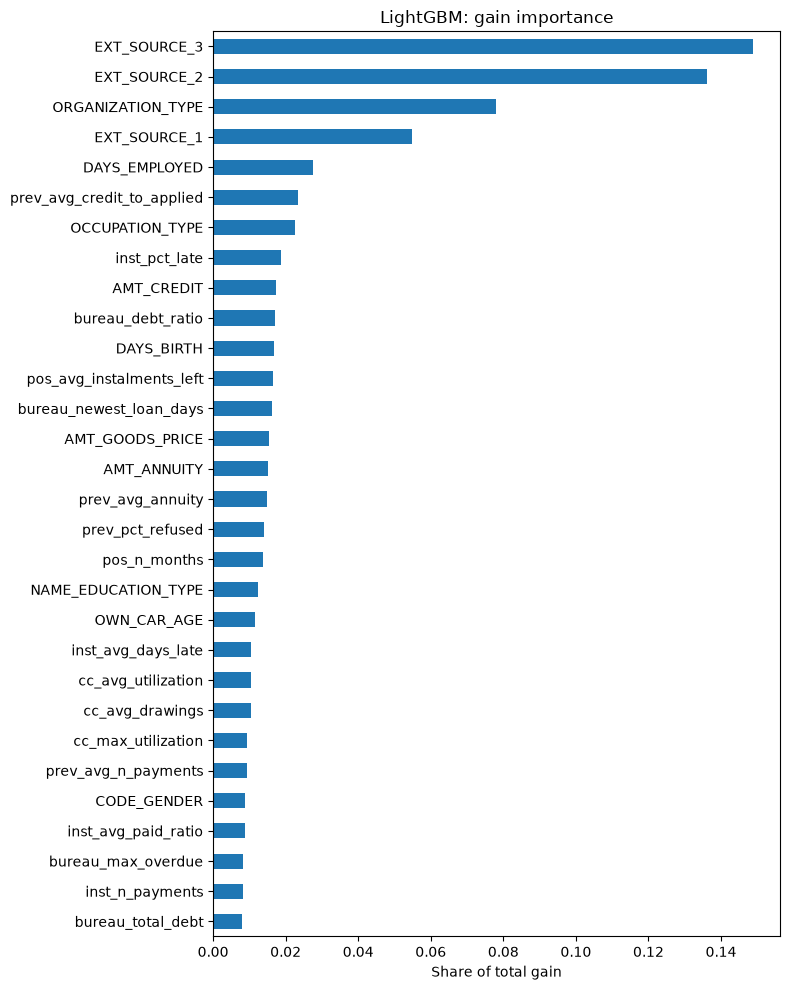

In [28]:
gain_imp = pd.Series(
    lgbm.booster_.feature_importance(importance_type="gain"),
    index=lgbm.booster_.feature_name()
)
gain_imp = (gain_imp / gain_imp.sum()).sort_values(ascending=False)

gain_imp.head(30).sort_values().plot.barh(figsize=(8, 10))
plt.title("LightGBM: gain importance")
plt.xlabel("Share of total gain")
plt.tight_layout()
plt.show()

In [29]:
X_shap = X_test_lgb.sample(5000, random_state=420)

contrib = lgbm.predict(X_shap, pred_contrib=True)

shap_values = pd.DataFrame(contrib[:, :-1], columns=X_shap.columns, index=X_shap.index)
shap_imp = shap_values.abs().mean().sort_values(ascending=False)


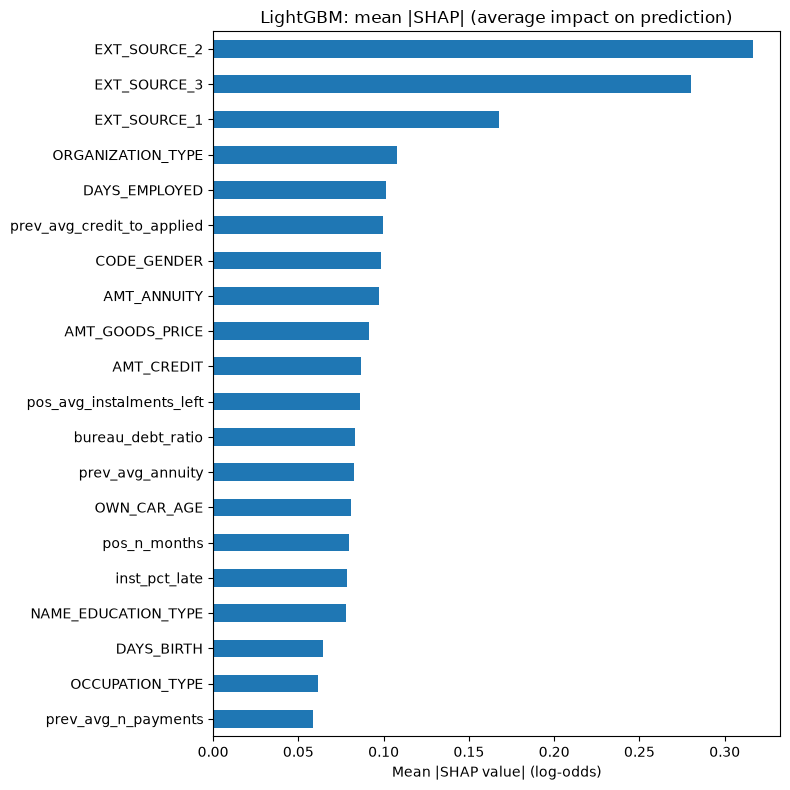

In [30]:
shap_imp.head(20).sort_values().plot.barh(figsize=(8, 8))
plt.title("LightGBM: mean |SHAP| (average impact on prediction)")
plt.xlabel("Mean |SHAP value| (log-odds)")
plt.tight_layout()
plt.show()


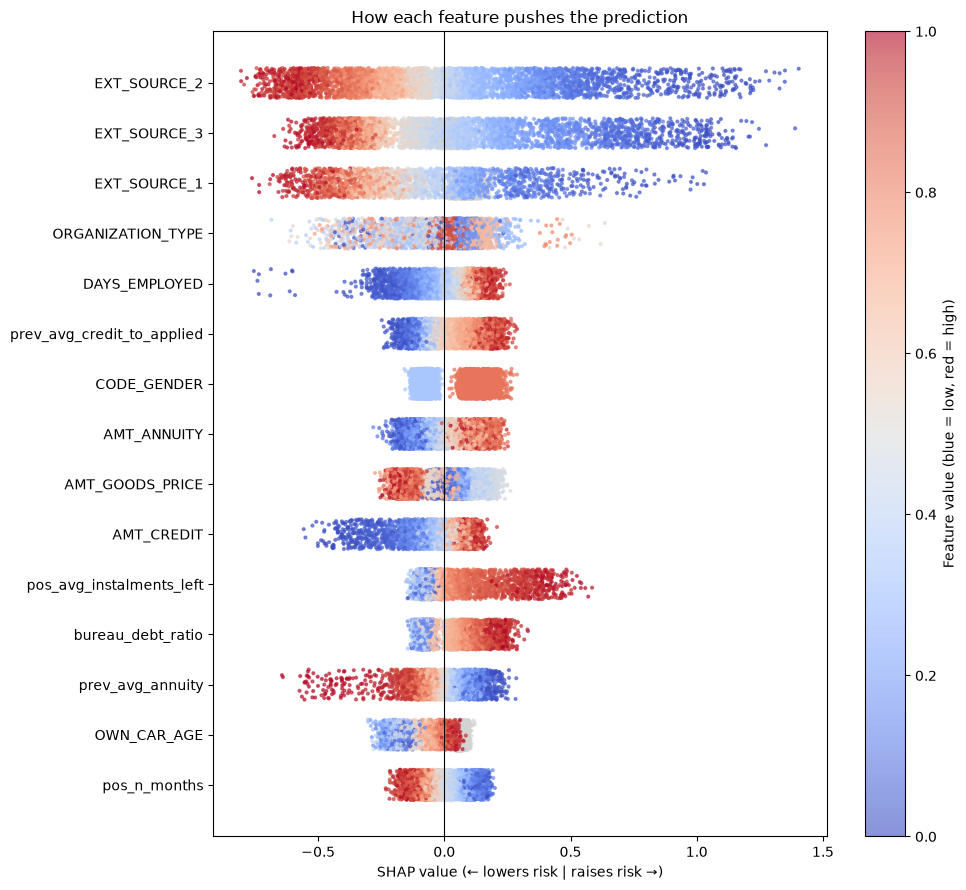

In [31]:
top = shap_imp.head(15).index[::-1] # most important at the top
rng = np.random.default_rng(420)

fig, ax = plt.subplots(figsize=(10, 9))
for i, col in enumerate(top):
    vals = X_shap[col]
    if vals.dtype.name == "category":
        vals = pd.Series(vals.cat.codes, index=vals.index).astype(float)
    color = vals.rank(pct=True) # 0 = lowest value, 1 = highest
    y = i + rng.uniform(-0.3, 0.3, len(vals)) # vertical jitter so dots don't overlap
    missing = color.isna().values

    ax.scatter(shap_values[col].values[missing], y[missing], color="lightgrey", s=4, alpha=0.5)
    sc = ax.scatter(shap_values[col].values[~missing], y[~missing], c=color.values[~missing],
                    cmap="coolwarm", vmin=0, vmax=1, s=4, alpha=0.6)

ax.set_yticks(range(len(top)))
ax.set_yticklabels(top)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP value (← lowers risk | raises risk →)")
ax.set_title("How each feature pushes the prediction")
fig.colorbar(sc, ax=ax, label="Feature value (blue = low, red = high)")
plt.tight_layout()
plt.show()


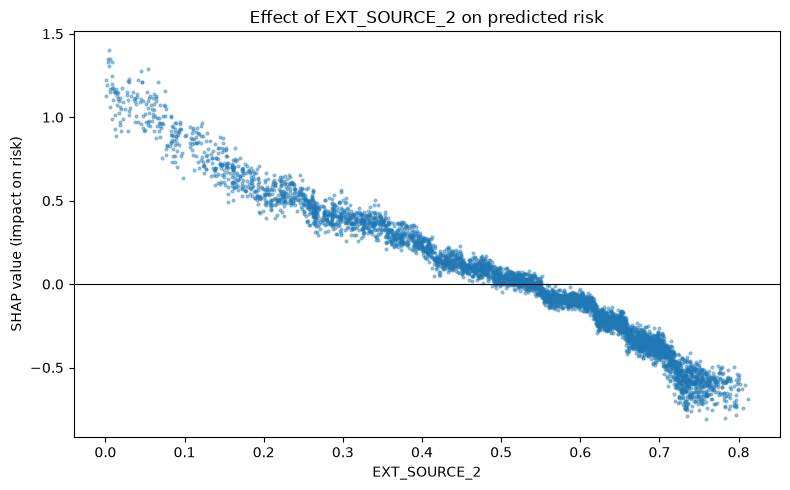

In [32]:
col = "EXT_SOURCE_2"

plt.figure(figsize=(8, 5))
plt.scatter(X_shap[col], shap_values[col], s=4, alpha=0.4)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel(col)
plt.ylabel("SHAP value (impact on risk)")
plt.title(f"Effect of {col} on predicted risk")
plt.tight_layout()
plt.show()


In [33]:
print(gain_imp.head(20))
print(shap_imp.head(20))

EXT_SOURCE_3                  0.148812
EXT_SOURCE_2                  0.136152
ORGANIZATION_TYPE             0.078095
EXT_SOURCE_1                  0.054803
DAYS_EMPLOYED                 0.027629
prev_avg_credit_to_applied    0.023322
OCCUPATION_TYPE               0.022644
inst_pct_late                 0.018632
AMT_CREDIT                    0.017398
bureau_debt_ratio             0.017026
DAYS_BIRTH                    0.016793
pos_avg_instalments_left      0.016374
bureau_newest_loan_days       0.016150
AMT_GOODS_PRICE               0.015489
AMT_ANNUITY                   0.015144
prev_avg_annuity              0.014939
prev_pct_refused              0.014148
pos_n_months                  0.013738
NAME_EDUCATION_TYPE           0.012383
OWN_CAR_AGE                   0.011484
dtype: float64
EXT_SOURCE_2                  0.316594
EXT_SOURCE_3                  0.280348
EXT_SOURCE_1                  0.167928
ORGANIZATION_TYPE             0.107882
DAYS_EMPLOYED                 0.101345
prev_avg_c

| Tier | Features | Evidence (Gain rank / SHAP rank) |
|---|---|---|
| **1: Dominant** | `EXT_SOURCE_2`, `EXT_SOURCE_3`, `EXT_SOURCE_1` | Top 4 in gain (2 / 1 / 4, together ~34% of total gain) and top 3 in SHAP (1 / 2 / 3) |
| **2: Strong** | `ORGANIZATION_TYPE`, `DAYS_EMPLOYED`, `prev_avg_credit_to_applied` | Top 6 in both methods (3/4, 5/5, 6/6) |
| **3: Loan terms** | `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE` | Ranked 8–15 in both (9/10, 15/8, 14/9) |
| **4: Credit history** | `bureau_debt_ratio`, `inst_pct_late`, `pos_avg_instalments_left`, `prev_avg_annuity`, `pos_n_months` | Top 18 in both (10/12, 8/16, 12/11, 16/13, 18/15) |
| **5: Demographics** | `DAYS_BIRTH`, `NAME_EDUCATION_TYPE`, `OCCUPATION_TYPE`, `OWN_CAR_AGE` | Top 20 in both (11/18, 19/17, 7/19, 20/14) |
| **Only one method** | `CODE_GENDER`, `bureau_newest_loan_days`, `prev_pct_refused`, `prev_avg_n_payments` | Top 20 in only one method (SHAP 7; gain 13; gain 17; SHAP 20) |


# Data Analysis into Features

In [34]:
df_target_gp = (
    df.groupby("TARGET")[["EXT_SOURCE_2", "EXT_SOURCE_1", "EXT_SOURCE_3"]]
    .agg(
         ["count", "mean", "median", "std", "min",
         lambda s: s.quantile(0.25), lambda s: s.quantile(0.75), "max"]
    )
)
df_target_gp = df_target_gp.rename(columns={"<lambda_0>": "q25", "<lambda_1>": "q75"})
df_target_gp.T

TARGET                          0             1
EXT_SOURCE_2 count   2.820780e+05  24773.000000
             mean    5.234787e-01      0.410935
             median  5.739047e-01      0.440381
             std     1.862767e-01      0.213107
             min     8.173617e-08      0.000005
             q25     4.097866e-01      0.238568
             q75     6.677051e-01      0.594190
             max     8.549997e-01      0.811870
EXT_SOURCE_1 count   1.240790e+05  10054.000000
             mean    5.114612e-01      0.386968
             median  5.174516e-01      0.361675
             std     2.088044e-01      0.204729
             min     1.456813e-02      0.014691
             q25     3.454303e-01      0.221847
             q75     6.828386e-01      0.537508
             max     9.626928e-01      0.929394
EXT_SOURCE_3 count   2.273980e+05  19148.000000
             mean    5.209690e-01      0.390717
             median  5.460232e-01      0.379100
             std     1.904650e-01      0.205810
             min     5.272652e-04      0.000527
             q25     3.859147e-01      0.223831
             q75     6.738301e-01      0.553165
             max     8.939761e-01      0.896010

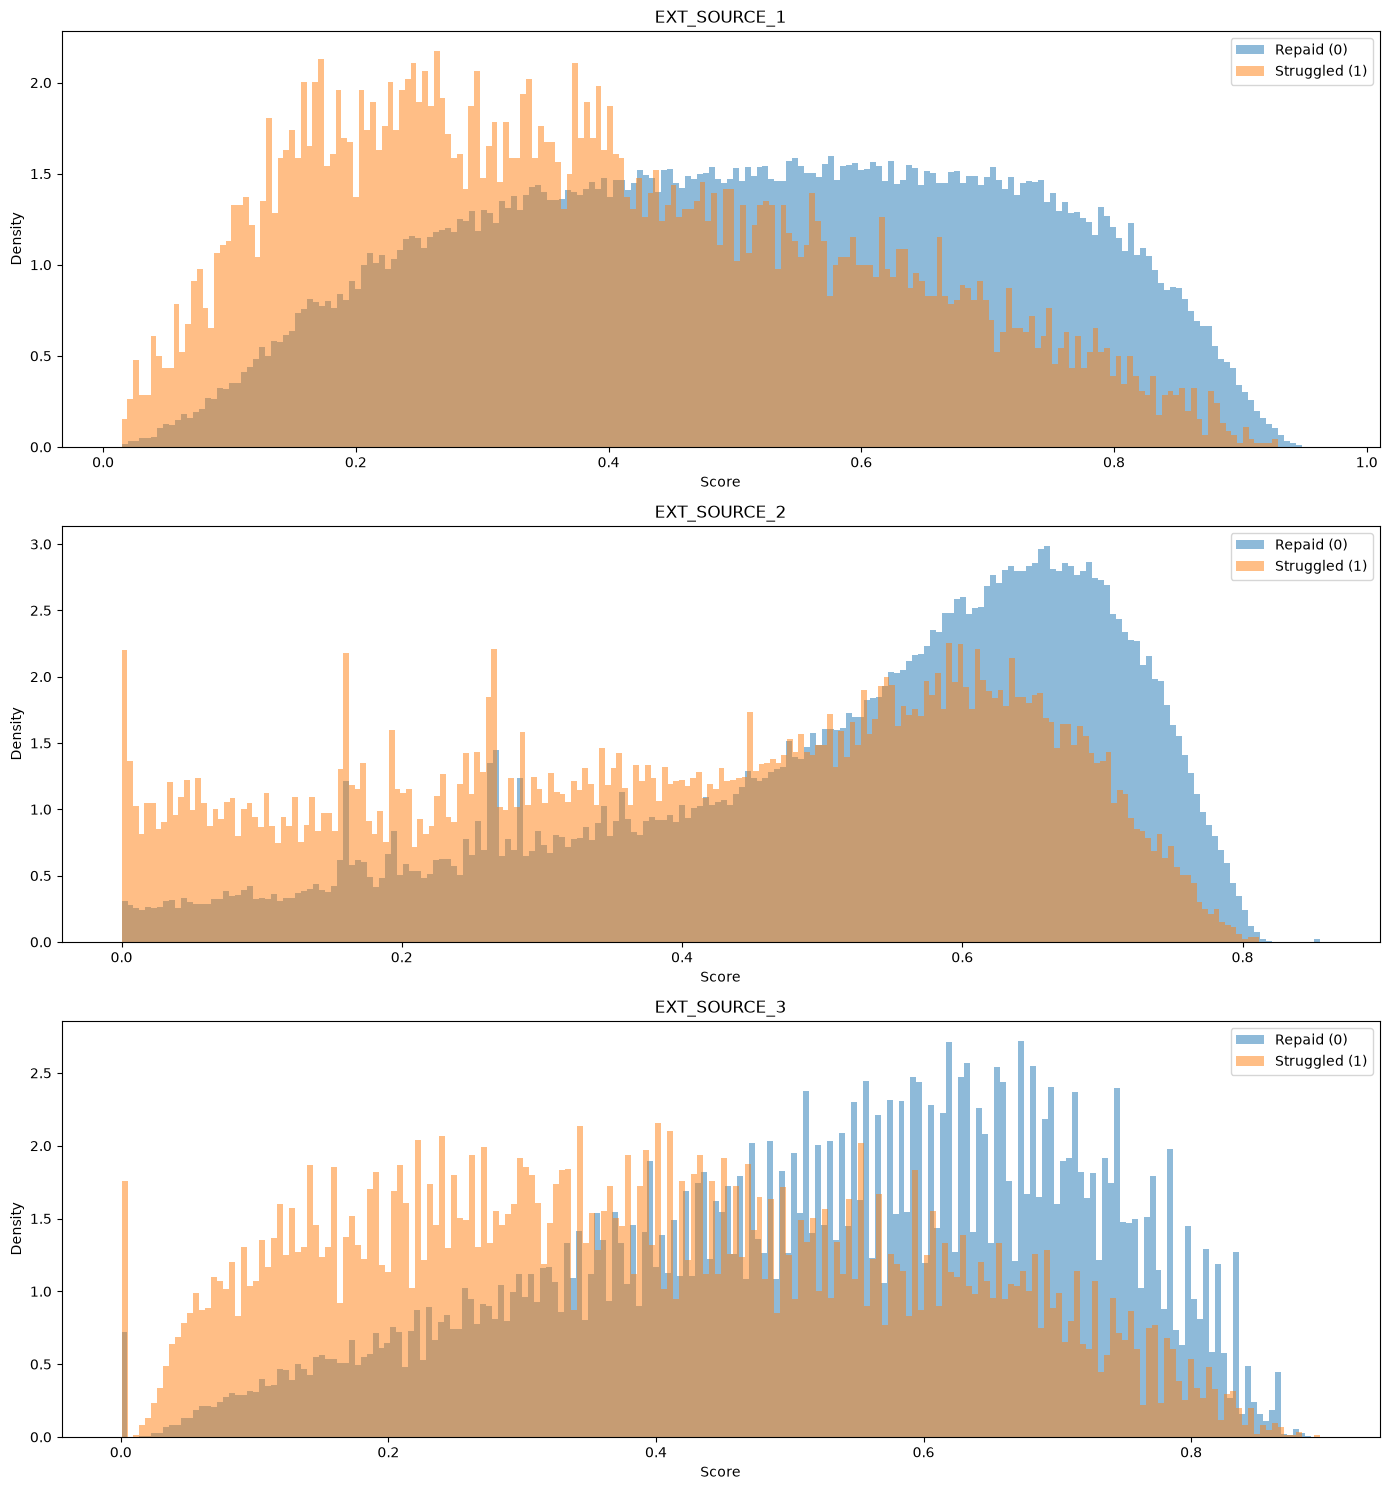

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for ax, col in zip(axes, ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]):
    ax.hist(df.loc[df["TARGET"] == 0, col].dropna(), bins=200, density=True, alpha=0.5, label="Repaid (0)")
    ax.hist(df.loc[df["TARGET"] == 1, col].dropna(), bins=200, density=True, alpha=0.5, label="Struggled (1)")
    ax.set_title(col)
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()


# Notes
Whats interesting here is the credit scores seem to be oddly distributed.
- External source one it make sense that those who struggled to pay off loans were in the lower range, however those who didn't struggle had a uniform distribution.
- In External source two the shape of the graph aligns more with the logic that higher scores indicate individuals not struggling to pay off debt, meanwhile those with lower scores tend to struggle more. 
- External source 3 also is similar to External source 2 with the distribution being highly skewed. 


In [36]:
df_organization = pd.crosstab(df["ORGANIZATION_TYPE"], df["TARGET"])
df_organization.columns = ["repaid", "struggled"]

df_organization["total"] = df_organization["repaid"] + df_organization["struggled"]
df_organization["default_rate_%"] = (df_organization["struggled"] / df_organization["total"] * 100).round(1)

df_organization.sort_values("default_rate_%", ascending=False)


,repaid,struggled,total,default_rate_%
ORGANIZATION_TYPE,,,,
Transport: type 3,1000,187,1187,15.8
Industry: type 13,58,9,67,13.4
Industry: type 8,21,3,24,12.5
Construction,5936,785,6721,11.7
Restaurant,1599,212,1811,11.7
Cleaning,231,29,260,11.2
Industry: type 1,924,115,1039,11.1
Realtor,354,42,396,10.6
Industry: type 3,2930,348,3278,10.6


# NOTE
Upon looking at the Organizational type an individual or applicant is a part of there isn't a specific organization that we can supportively claim primarily struggles in repaying debt back. However, there is a patter across the groups though with jobs that are lower risk have a Default Rate below 5% while those that are at Higher Risk have (10% - 16%)

In [37]:
df["YEARS_EMPLOYED"] = -df["DAYS_EMPLOYED"] / 365

print("No employer (placeholder 365243):")
print(df.groupby("NO_EMPLOYER")["TARGET"].agg(clients="count", default_rate="mean"))
print()

df.groupby("TARGET")["YEARS_EMPLOYED"].describe().T


No employer (placeholder 365243):
             clients  default_rate
NO_EMPLOYER                       
0             252137      0.086600
1              55374      0.053996



TARGET,0,1
count,230302.000000,21835.000000
mean,6.679836,4.972380
std,6.499752,5.067783
min,-0.000000,-0.000000
25%,2.161644,1.627397
50%,4.632877,3.369863
75%,8.915068,6.521918
max,49.073973,44.024658


# Note
This is a weird one because the days employed are negative. This is just because there calculating or tracking the number of days since the previous application the person has been employed. Moreover, I convereted all of the times for each individual to be by how many years they have been employed. As we can see that the average number is 6.7 years. As we can see those who didn't struggle paying of debt, have worked longer comapred to those who struggle with paying off debt. 

In [38]:
df_prev_credit = (df.groupby("TARGET")["prev_avg_credit_to_applied"].describe()
                  )

df_prev_credit.T


TARGET,0,1
count,266253.000000,23789.000000
mean,1.016104,1.040652
std,0.101499,0.122699
min,0.200000,0.300150
25%,0.971014,0.992088
50%,1.018778,1.044000
75%,1.074249,1.099000
max,6.626399,10.180000


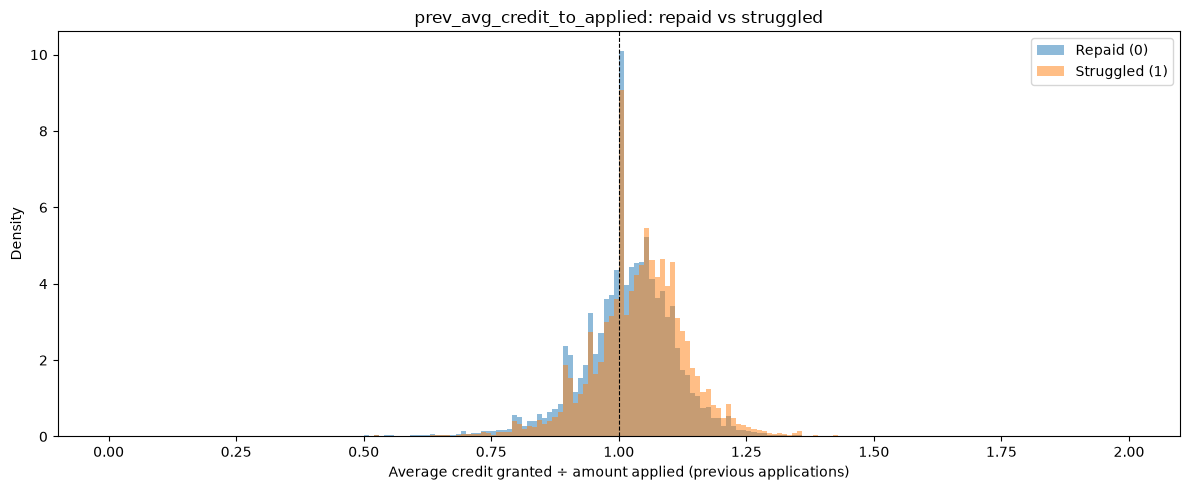

In [39]:
plt.figure(figsize=(12, 5))
for t, label in [(0, "Repaid (0)"), (1, "Struggled (1)")]:
    plt.hist(df.loc[df["TARGET"] == t, "prev_avg_credit_to_applied"].dropna(),
             bins=200, range=(0, 2), density=True, alpha=0.5, label=label)
plt.axvline(1, color="black", linestyle="--", linewidth=0.8)   # got exactly what they asked for
plt.xlabel("Average credit granted ÷ amount applied (previous applications)")
plt.ylabel("Density")
plt.title("prev_avg_credit_to_applied: repaid vs struggled")
plt.legend()
plt.tight_layout()
plt.show()


# NOTE 
Important to understand the prev_avg_credit_to_applied is a measure of how risky their asked and if they got from their previous application. Essentially this is tracking how risky/ how much the loaners trusted or gave on how they feel the applicant should get given their history. As seen those who struggled to pay off debt tended to ask for more money and thus had a higher ask to given rate. Those who dont struggle often asked less and got more for what they applied for. Most meaningful are those who asked and got exactly what they wanted (center of 1). This is important to understand because the 1 gave an applicant how much they applied for. 

# Building the Neaural Netwrok
#### Description: This bellow is where we will test different neural netwroks. We need to test out different parameters and optimizers to teach our model the most effective approach. Moreoover, we will see if embedding or a library approach will be the most optimized model. 

In [40]:
import copy
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import rankdata

### Things we need to do to fix the data up to be prepared for running into the NN

In [41]:
def signed_log(d):
    """
    This function will use log1p to help the NN handle negative values
    """
    return np.sign(d) * np.log1p(np.abs(d))

def fit_numeric_prep(df):
    df = df.astype(float)
    # helps us find symmetrical data (As seen above there was an issue of some of the data being skewed) This log function will help us fix this issue
    skew = df.skew() 
    log_cols = skew[skew.abs() > 2].index.tolist() # anything skewed by more than two will be marked and run trhough log
    if log_cols:
        df[log_cols] = signed_log(df[log_cols])
    missing_cols = df.columns[df.isna().any()].tolist()
    medians = df.median() # similar to the random forrest and the LightGBM we will apply medians to nan values
    filled = df.fillna(medians)
    return {
        "log_cols": log_cols,
        "missing_cols": missing_cols,
        "medians": medians,
        "means": filled.mean(),
        "stds": filled.std().replace(0, 1)
    }

def transform_numeric(df, p):
    df = df.astype(float)
    if p["log_cols"]:
        df[p["log_cols"]] = signed_log(df[p["log_cols"]])
    missing = df[p["missing_cols"]].isna().astype(float).add_suffix("_missing") # to help us track which data (has missing values) since we are applying the median
    df = df.fillna(p["medians"])
    df = ((df - p["means"]) / p["stds"]).clip(-5, 5)    # standardise, then clip the result
    # normalizing but making sure its normalized between -5 and 5. We do not wan't our spread to be crazy large
    return pd.concat([df, missing], axis=1)

# Data Testing:
#### Based off of our analytics above, we are goign to test two different approaches. 
1. Based off of the two models and what they considered to be the most important features used to classify the target based of applicant data, we are going to run the **TOP 30** features that were used by each model onto the NN
2. We are goign to then test all of the features that were used on the model to see if the NN will find signal in using all 167 features. **My hypothesis** on this approach is that it will overfit onto our training data. This is an issue because when we use the test datat it will not likley generalize to this data set which will not allow us to predict and classify the correct targets on each applicants. 

In [42]:
def cat_codes(df, cols): # category codes shifted by +1 so that 0 = "unseen category" (code -1 becomes 0)
    if not cols:
        return np.zeros((len(df), 0), dtype=np.int64)
    return np.stack([df[c].cat.codes.to_numpy().astype(np.int64) + 1 for c in cols], axis=1) # does... Index(['blue', 'red'], dtype='object') 

def build_nn_data(features):
    feats_cat = [c for c in features if c in cat_cols]
    feats_num = [c for c in features if c not in cat_cols] 

    p = fit_numeric_prep(X_fit[feats_num])
    data = {"cat_cards": [len(X_fit[c].cat.categories) + 1 for c in feats_cat]}

    for name, X_part, y_part in [("fit", X_fit, y_fit), ("val", X_val, y_val), ("test", X_test_lgb, y_test)]: 
        num = transform_numeric(X_part[feats_num], p)
        data[f"{name}_num"] = torch.tensor(num.to_numpy(dtype=np.float32))
        data[f"{name}_cat"] = torch.tensor(cat_codes(X_part, feats_cat), dtype=torch.long)
        data[f"{name}_y"] = torch.tensor(y_part.to_numpy(), dtype=torch.float32)

    data["n_num"] = data["fit_num"].shape[1]
    print(f"{len(features)} features -> {data["n_num"]} numeric inputs + {len(feats_cat)} embedded categories")
    return data

top30 = gain_imp.head(30).index.tolist()

data_all = build_nn_data(list(X_fit.columns))
data_top30 = build_nn_data(top30)

167 features -> 259 numeric inputs + 16 embedded categories
30 features -> 50 numeric inputs + 4 embedded categories


## TabularMLP Architecture

**Inputs**

| Input | Shape | Description |
|---|---|---|
| `x_num` | `(batch, n_num)` | Scaled numeric features |
| `x_cat` | `(batch, n_cat_cols)` | Integer category codes (0 = unseen/missing) |

**Embedding stage**

Each categorical column has its own `nn.Embedding(n, d)` table, where `n` is the number of categories + 1 and `d = min(10, (n + 1) // 2)`. The embedding vectors are concatenated with the numeric features:

`input_dim = n_num + sum(embedding dims)`

**Layers**

| # | Layer | Output size | Purpose |
|---|---|---|---|
| 0 | Embeddings + concat | `input_dim` | Combine numeric and categorical inputs |
| 1 | Linear → BatchNorm → ReLU → Dropout(0.3) | 256 | Hidden block 1 |
| 2 | Linear → BatchNorm → ReLU → Dropout(0.3) | 128 | Hidden block 2 |
| 3 | Linear → BatchNorm → ReLU → Dropout(0.3) | 64 | Hidden block 3 |
| 4 | Linear | 1 | Logit of default |

**Flow**

`x_cat → Embeddings ─┐`
`                    ├─ concat → 256 → 128 → 64 → 1 (logit)`
`x_num ──────────────┘`

**Output**

A single raw logit per row, shape `(batch,)`. The model has no sigmoid, so it is trained with `BCEWithLogitsLoss`, and `torch.sigmoid` is applied to get the probability of default.

In [43]:
class MLP(nn.Module): 
    def __init__(self, n_num, cat_cardinalities, hidden=(256, 128, 64), dropout=0.3):
        super().__init__() # One embedding table per categorical columns 
        self.embeddings = nn.ModuleList(
            [nn.Embedding(n, min(10, (n+1) // 2)) for n in cat_cardinalities] 
        ) # help train the model with data that can be read in pytorch. Essentially embeds the categorical data 
        in_dim = n_num + sum(e.embedding_dim for e in self.embeddings) # creates the dimensions needed with the embedded categorical matrix along with the numerical matrix

        layers = []
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1)) # this is the output the prediction
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, x_cat):
        embeded = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat([x_num] + embeded, dim = 1)
        return self.mlp(x).squeeze(1) # squeez means combining all of the results to 1 result...
            

# Training the Model

**Test different batches to do hyperparameter tuning**

for bs in [256, 512, 1024, 2048]:
    ...  # pass batch_size=bs into the DataLoader in train_nn, compare best val AUC


In [44]:
def predict_proba_nn(model, x_num, x_cat, batch_size=8192): 
    model.eval() # initializing the evaluation for the model
    out = []
    with torch.no_grad():
        for i in range(0, len(x_num), batch_size):
            out.append(torch.sigmoid(model(x_num[i:i + batch_size], x_cat[i:i + batch_size])))
        return torch.cat(out).numpy()

def train_nn(data, pos_weight=None, epoch=50, patience=5, lr=1e-3, seed=420):
    torch.manual_seed(seed) # seed for mode and everything is 420
    model = MLP(data["n_num"], data["cat_cards"])
    
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=None if pos_weight is None else torch.tensor(pos_weight))
    # Context of loss function: This will help us calculate a better loss of learning within the model
    # This loss fn is mainly a function to help with massive amounts of class imabalance within the data
    
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    # Use of this optimizer is to create momentum by using recent gradients to update weight
    # tracks how large each gradient for each weight gests 
    # each weight is slowly shrining towards zero
    # discourages large weights, which is a mild form of regularization against overfitting
    
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode ="max", factor=0.5, patience=2)
    # Essentially helps reduce the learning rate. WIll reduce the learning rate more by 0.5 every 2 epoch. 
    # helps us fix the lr as the model learns. essentially saving us time and reruns of trying different learning rates

    loader = DataLoader(
        TensorDataset(data["fit_num"], data["fit_cat"], data["fit_y"]),
        batch_size=1024, shuffle=True, drop_last=True # BatchNorm can't handle a Batch of 1
    )

    best_auc, best_state, bad_epoch, history = 0.0, None, 0, []
    for epoch in range(1, epoch+1):
        model.train()
        total_loss = 0.0
        for xb_num, xb_cat, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb_num, xb_cat), yb)
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(yb) # storing the loss in training each time
        val_auc = roc_auc_score(data["val_y"].numpy(), predict_proba_nn(model, data["val_num"], data["val_cat"]))
        sched.step(val_auc) #seeing whether to lower the lr
        history.append({"epoch": epoch, "train_loss": total_loss / len(loader.dataset), "val_auc": val_auc})
        print(f"epoch {epoch}  train loss {history[-1]['train_loss']:.2}  val AUC {val_auc:.2}")

        if val_auc > best_auc + 1e-4:
            best_auc, best_state, bad_epoch = val_auc, copy.deepcopy(model.state_dict()), 0 
        else:
            bad_epoch += 1
            if bad_epoch >= patience:
                print(f"early stop - best val AUC {best_auc:.2}")
                break

    model.load_state_dict(best_state) # keep the best epoch, not the last one
    return model, pd.DataFrame(history)
            

#### Training all 4 versions and comparing them to see which one has the beset fit....

In [45]:
pos_weight = float((y_fit == 0).sum() / (y_fit == 1).sum()) # around 11.4 this is just a bassis of how many 1 to 0 target there are 

results, trained = [], {}
for feat_name, data in [("all", data_all), ("top30", data_top30)]:
    for weight_name, pw in [("weighted", pos_weight), ("unweighted", None)]:
        print(f"\n--{feat_name} features, {weight_name} ---")
        nn_model, hist =  train_nn(data, pos_weight=pw) # training
        test_p = predict_proba_nn(nn_model, data["test_num"], data["test_cat"]) # getting the probability dist
        trained[(feat_name, weight_name)] = (nn_model, hist, test_p)
        results.append({
            "features": feat_name, # grabs the features to index with teh weights
            "weigting": weight_name, # grabs the final weights
            "epoch": len(hist),
            "best_val_auc": hist["val_auc"].max(), #grabs best AUC from the list
            "test_auc": roc_auc_score(y_test, test_p), #
            "test_pr_auc": average_precision_score(y_test, test_p)
        })

results_nn = pd.DataFrame(results).round(4)
results_nn


--all features, weighted ---


epoch 1  train loss 1.1  val AUC 0.76
epoch 2  train loss 1.1  val AUC 0.76
epoch 3  train loss 1.1  val AUC 0.76
epoch 4  train loss 1.0  val AUC 0.76
epoch 5  train loss 1.0  val AUC 0.77
epoch 6  train loss 1.0  val AUC 0.77
epoch 7  train loss 1.0  val AUC 0.76
epoch 8  train loss 1.0  val AUC 0.77
epoch 9  train loss 1.0  val AUC 0.76
epoch 10  train loss 1.0  val AUC 0.77
epoch 11  train loss 1.0  val AUC 0.76
epoch 12  train loss 0.98  val AUC 0.76
epoch 13  train loss 0.97  val AUC 0.76
early stop - best val AUC 0.77

--all features, unweighted ---
epoch 1  train loss 0.36  val AUC 0.76
epoch 2  train loss 0.25  val AUC 0.76
epoch 3  train loss 0.25  val AUC 0.76
epoch 4  train loss 0.25  val AUC 0.76
epoch 5  train loss 0.24  val AUC 0.76
epoch 6  train loss 0.24  val AUC 0.76
epoch 7  train loss 0.24  val AUC 0.76
epoch 8  train loss 0.24  val AUC 0.76
epoch 9  train loss 0.24  val AUC 0.77
epoch 10  train loss 0.24  val AUC 0.76
epoch 11  train loss 0.24  val AUC 0.76
epoch 

,features,weigting,epoch,best_val_auc,test_auc,test_pr_auc
0,all,weighted,13,0.7665,0.7748,0.2692
1,all,unweighted,14,0.7665,0.7734,0.2645
2,top30,weighted,17,0.7635,0.7740,0.2655
3,top30,unweighted,23,0.7619,0.7731,0.2633


# Visualizing the results  

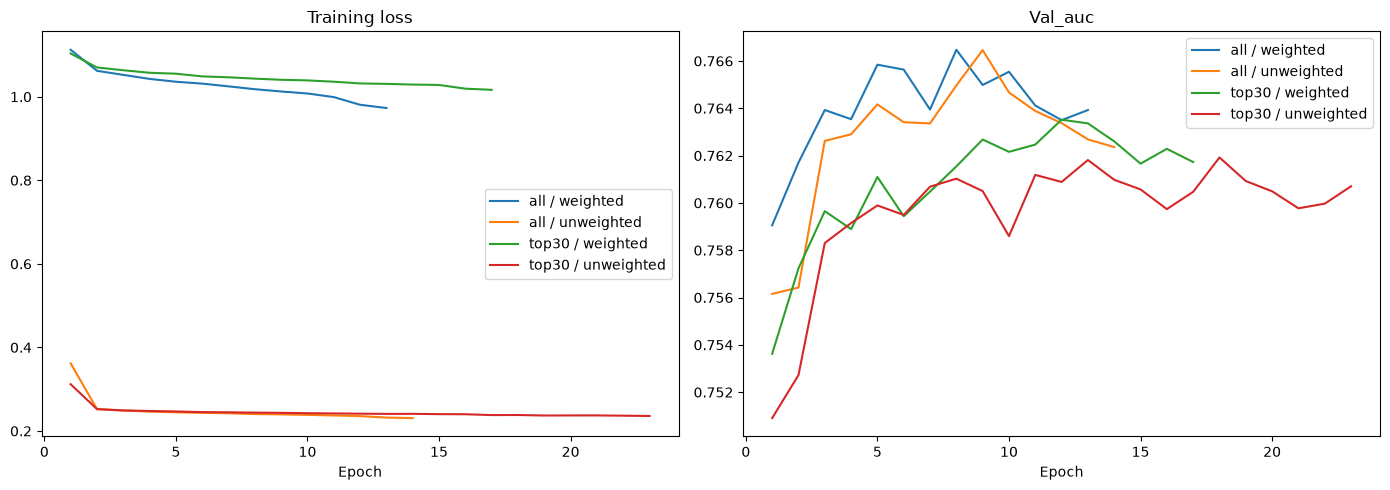

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for key, (_, hist, _) in trained.items():
    label = f"{key[0]} / {key[1]}"
    axes[0].plot(hist["epoch"], hist["train_loss"], label=label)
    axes[1].plot(hist["epoch"], hist["val_auc"], label=label)
axes[0].set_title("Training loss"); axes[0].set_xlabel("Epoch")
axes[1].set_title("Val_auc"); axes[1].set_xlabel("Epoch")
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.show()


# Notes & Conclusion 

A clear distinction between all of our models is their training loss. Both **weighted** models had the highest training loss, while the unweighted models had low training loss. The higher training loss doesn't mean that the models is underfitting or overfitting. In fact, with the smoothing out of the curve for the training loss, it indicates that the model is slowly fitting our data and being able to learn and generalize it's classification. This is particulaarly seen wit all/ weighted with a high AUC along with a slowly decending trianing loss. For the unweighted models, the low training loss doesn't reflecting a better model. In fact it indcates the model is overfititng. For example, top30/ unweighted continuefs to smooth out and lower's its training loss towards 0. This is an issue because this indicates the model may be overfitting. 

Overall, the take from running all four model types shows us that all factors produce signal the NN needs to determine whether a applicant will or will not struggle with paying off their debt.

# Ethical Concern....

While these models are going to be used to help with determining whether or not someone can pay off their loans, the scope of this project can only applied to the current applicants that the data represents. Moreover, using such a model holds its problems. As we can see the model holds an AUC of 0.76 with the weighted/ all features. Though the information contains a lot on applicant backgrond, the model can make mistakes on classifying a applicant struggling or not. That is why its important to still research the associative features we have found from modeling with differen ML (Random Forrest & LightGBM).